In [3]:
#Bài 1
import folium
from folium import plugins
ueh = folium.Map(location=[10.761047, 106.668346],zoom_start=16)
fg_ueh = folium.FeatureGroup(name='Đại học Kinh tế TP.HCM')
fg_public = folium.FeatureGroup(name='Địa điểm công cộng')
folium.Marker([10.761047, 106.668346],popup="Đại Học Kinh Tế TP.HCM cơ sở B", tooltip="Click để xem thông tin",icon=folium.Icon(color='red', icon='book')).add_to(fg_ueh)
folium.Marker([10.760563, 106.666698],popup="Bệnh viện Hòa Hảo", tooltip="Click để xem thông tin",icon=folium.Icon(color='purple', icon='plus')).add_to(fg_public)
folium.Marker([10.763186, 106.668299],popup="Trường THCS Hoàng Văn Thụ", tooltip="Click để xem thông tin",icon=folium.Icon(color='purple', icon='book')).add_to(fg_public)
folium.Marker([10.758064, 106.665784],popup="Bệnh viện Phạm Ngọc Thạch", tooltip="Click để xem thông tin",icon=folium.Icon(color='purple', icon='plus')).add_to(fg_public)
folium.Marker([10.762720, 106.668172],popup="CP Fresh Mart", tooltip="Click để xem thông tin",icon=folium.Icon(color='purple', icon='shopping-cart')).add_to(fg_public)
folium.Marker([10.761609, 106.670905],popup="Chi Cục Phát Triển Nông Thôn", tooltip="Click để xem thông tin",icon=folium.Icon(color='purple', icon='leaf')).add_to(fg_public)
fg_ueh.add_to(ueh)
fg_public.add_to(ueh)
folium.LayerControl().add_to(ueh)
plugins.Fullscreen().add_to(ueh)
ueh

In [ ]:
#Bài 2
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
ueh = "279 Nguyen Tri Phuong, Dien Hong, Ho Chi Minh City"
geolocator = Nominatim(user_agent="baitapAI", timeout=20)
ueh_addr = geolocator.geocode(ueh)
ueh_toado = (ueh_addr.latitude, ueh_addr.longitude)
m = folium.Map(location=ueh_toado, zoom_start=15)
diadiem = [
    "Benh vien Hoa Hao",
    "Hoang Van Thụ Secondary School",
    "Benh vien Pham Ngoc Thach",
    "Cong vien Van Lang",
    "San van dong Thong Nhat",
    "Cho Nguyen Tri Phuong",
    "Benh vien Nhi dong 1",
    "Hung Vuong Plaza",
    "Chua An Quang",
    "Dai hoc Y Duoc TPHCM"
]
for addr in diadiem:
  location=geolocator.geocode(addr)
  if location:
    toado=(location.latitude, location.longitude)
    khoangcach=geodesic(ueh_toado, toado).km
    folium.Marker(location=ueh_toado,tooltip="<b>CENTER:</b> Đại học Kinh tế TP.HCM cơ sở B",
      icon=folium.Icon(color='red', icon='book')
    ).add_to(m)
    folium.Marker(location=toado,tooltip=addr, popup=f"Địa chỉ: {addr}<br>Cách UEH: {round(khoangcach, 2)} km",
        icon=folium.Icon(color='purple', icon='star')
        ).add_to(m)
    folium.PolyLine(
        locations=[ueh_toado, toado],
        color='blue',
    ).add_to(m)
    time.sleep(1)
m

In [14]:
#Bài 3
from folium.plugins import HeatMap
import numpy as np
import pandas as pd
ueh_b = [10.761, 106.668]
m = folium.Map(location=ueh_b, zoom_start=16)
data = []
for _ in range(200):
    vido = ueh_b[0] + np.random.uniform(-0.005, 0.005)
    kinhdo = ueh_b[1] + np.random.uniform(-0.005, 0.005)
    donhang = np.random.randint(10, 100)
    data.append([vido, kinhdo, donhang])
HeatMap(data,radius=25,blur=15,min_opacity=0.5,
    gradient={0.4: 'green', 0.65: 'yellow', 1: 'red'}
).add_to(m)
m

Ý nghĩa quản trị của các vùng nóng trên bản đồ:
- Giúp nhận diện sớm khu vực có nguy cơ quá tải đơn hàng để điều phối hợp lý
- Hỗ trợ chọn chỗ đặt kho, tủ lấy hàng thông minh
- Vùng nóng là khu vực tiềm năng, từ đó đưa chiến lược dịch vụ,...

In [9]:
#Bài 4
import numpy as np
import geopandas as gpd
url_usa = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/us-states.json"
gdf_usa = gpd.read_file(url_usa)
tieuthu = pd.DataFrame({
    'bang_id': gdf_usa['id'],
    'chi_so': np.random.randint(10, 100, size=len(gdf_usa['id']))})
m = folium.Map(location=[37, -102], zoom_start=4)
folium.Choropleth(
    geo_data=gdf_usa,name="choropleth",data=tieuthu,columns=['bang_id', 'chi_so'],key_on='feature.properties.id',fill_color='RdPu',
    line_opacity=0.2,
    legend_name='Mức độ tiêu thụ thức ăn nhanh (%)',
).add_to(m)
m

Ý nghĩa quản trị:
- Bản đồ trên cho thấy sự khác biệt về mức độ tiêu thụ giữa các khu vực, từ đó giúp nhà quản lý:
+ Xác định khu vực tiêu thụ cao để ưu tiên phân bổ nhàng hóa, nhân lực
+ Xác định khu vực tiêu thụ thấp để điều chỉnh chiến lược
+ Hỗ trợ chọn chỗ đặt kho, mở chi nhánh, tối ưu mạng lưới phân phối.

In [6]:
#Bài 5
center_toado = [10.7599, 106.6675] 
m = folium.Map(location=center_toado, zoom_start=12)
folium.Marker(location=center_toado,tooltip="<b>TRUNG TÂM PHÂN PHỐI</b>",icon=folium.Icon(color='red')).add_to(m)
folium.Circle(location=center_toado,radius=3000, color='yellow',tooltip="Bán kính 3km").add_to(m)
folium.Circle(location=center_toado,radius=5000,color='orange',tooltip='Bán kính 5km').add_to(m)
folium.Circle(location=center_toado,radius=10000,color='red',tooltip="Bán kinh 10km").add_to(m)
m

Đánh giá khả năng tiếp cận khách hàng của từng vùng:
- Vùng 3km: Khả năng tiếp cận cao nhất do khoảng cách gần, thời gian giao hàng nhanh, chi phí thấp
- Vùng 5km: Khả năng tiếp cận trung bình, vẫn có thể đảm bảo thời gian giao hàng hợp lý
- Vùng 10km: Khả năng tiếp cận thấp hơn do khoảng cách xa, thời gian giao hàng dài và chi phí cao
Đề xuất phạm vi hoạt động tối ưu:
- Vùng 5km tối ưu vì cân bằng giữa khả năng tiếp cận khách hàng và chi phí vận hành.Vùng 3km nên được ưu tiên phục vụ nhanh, còn vùng 10km chỉ nên khai thác khi nhu cầu cao.


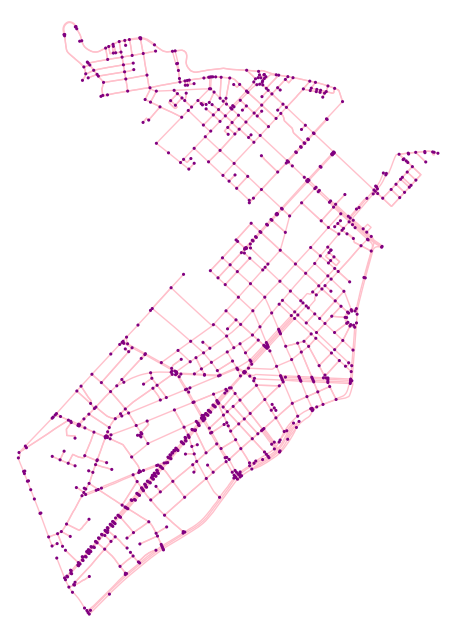

Phân Tích 
1. Số lượng nút giao: 989
2. Chiều dài đường trung bình: 79.03 mét


In [5]:
#Bài 6
import osmnx as ox
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(graph, node_size=5, node_color='purple', edge_color='pink', bgcolor='white')
stats = ox.basic_stats(graph)
print("Phân Tích ")
print(f"1. Số lượng nút giao: {stats['n']}")
print(f"2. Chiều dài đường trung bình: {round(stats['edge_length_avg'], 2)} mét")

Vai trò của dừ liệu mạng giao thông trong các hệ thống AI đô thị thông minh:
- Hỗ trợ hệ thống gọi xe và logistics
- Quy hoạch đô thị thông minh
- Dự đoán và giảm ùn tắc
- Đề xuất giải pháp điều phối
- Tối ưu hóa tuyến đường, giảm thời gian di chuyển

In [36]:
#Bài 7
import networkx as nx
diadiem = "District 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(diadiem, network_type='drive')
toado_di = (10.7797, 106.6992)
toado_den = (10.7719, 106.6983)
nut_di = ox.nearest_nodes(graph, toado_di[1], toado_di[0])
nut_den = ox.nearest_nodes(graph, toado_den[1], toado_den[0])

path_d = nx.shortest_path(graph, nut_di, nut_den, weight='length', method='dijkstra')
def heuristic(u, v):
    u_coords = (graph.nodes[u]['y'], graph.nodes[u]['x'])
    v_coords = (graph.nodes[v]['y'], graph.nodes[v]['x'])
    return ox.distance.great_circle(u_coords[0], u_coords[1], v_coords[0], v_coords[1])

path_a = nx.astar_path(graph, nut_di, nut_den, weight='length', heuristic=heuristic)

def get_coords(path):
    return [(graph.nodes[node]['y'], graph.nodes[node]['x']) for node in path]

m = folium.Map(location=toado_di, zoom_start=15)
folium.PolyLine(get_coords(path_d), color="blue",weight=8, opacity=0.4, tooltip='Dijkstra').add_to(m)
folium.PolyLine(get_coords(path_a), color="red", tooltip='A*').add_to(m)
folium.Marker(toado_di, popup="Điểm đi", icon=folium.Icon(color='green')).add_to(m)
folium.Marker(toado_den, popup="Điểm đến", icon=folium.Icon(color='red')).add_to(m)
m

Phân tích ưu – nhược điểm của từng phương pháp:
1. Thuật toán Dijkstra
Ưu điểm:
+ Luôn tìm được đường đi ngắn nhất tối ưu toàn cục
+ Không cần thông tin bổ sung (heuristic)
+ Kết quả ổn định, chính xác
Nhược điểm:
+ Phải duyệt nhiều node nên tốn thời gian hơn
+ Không hiệu quả với bản đồ lớn, nhiều nút giao thông

2. Thuật toán A*
Ưu điểm:
+ Sử dụng heuristic nên tìm nhanh hơn
+ Giảm số lượng node cần duyệt
+ Hiệu quả cao trong bản đồ thực tế
Nhược điểm:
+ Phụ thuộc vào heuristic: nếu heuristic không tốt → kết quả kém hiệu quả

In [37]:
#Bài 8
import random
khuvuc = "District 1, Ho Chi Minh City, Vietnam"
dothi = ox.graph_from_place(khuvuc, network_type='drive')
nut = list(dothi.nodes())
khach = random.sample(nut, 3)
xe = random.sample(nut, 5)

m = folium.Map(location=[10.7769, 106.7009], zoom_start=15)
for nut_khach in khach:
    vi_tri = (dothi.nodes[nut_khach]['y'], dothi.nodes[nut_khach]['x'])
    folium.Marker(vi_tri, icon=folium.Icon(color='green',icon='walking',prefix='fa')).add_to(m)
xe_co_khach = []
for nut_khach in khach:
    khoang_cach_ngan_nhat = 999999
    xe_gan = None
    duong_di_tot_nhat = None
    for nut_xe in xe:
        if nut_xe not in xe_co_khach:
            try:
                do_dai = nx.shortest_path_length(dothi, nut_xe, nut_khach, weight='length')
                if do_dai < khoang_cach_ngan_nhat:
                    khoang_cach_ngan_nhat = do_dai
                    xe_gan = nut_xe
                    duong_di_tot_nhat = nx.shortest_path(dothi, nut_xe, nut_khach, weight='length')
            except:
                continue
    if xe_gan is not None:
        xe_co_khach.append(xe_gan)
        toado_duong = []
        for nut in duong_di_tot_nhat:
            y = dothi.nodes[nut]['y']
            x = dothi.nodes[nut]['x']
            toado_duong.append((y, x))
        folium.PolyLine(toado_duong, color="red", weight=5).add_to(m)
        vi_tri_xe = (dothi.nodes[xe_gan]['y'], dothi.nodes[xe_gan]['x'])
        folium.Marker(vi_tri_xe,icon=folium.Icon(color='red',icon='taxi',prefix='fa')).add_to(m)
m

In [ ]:
#Bài 9
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd
np.random.seed(42)
lat_coords = np.random.uniform(10.76, 10.79, 100)
lon_coords = np.random.uniform(106.68, 106.71, 100)
data_donhang = pd.DataFrame({'lat': lat_coords, 'lon': lon_coords})
model_kmeans = KMeans(n_clusters=3, random_state=42)
data_donhang['cum_id'] = model_kmeans.fit_predict(data_donhang[['lat', 'lon']])
vi_tri_kho_hang = model_kmeans.cluster_centers_
m = folium.Map(location=[10.7769, 106.7009], zoom_start=14)

clr = ['blue', 'green', 'orange']
for i in range(len(data_donhang)):
    donhang = data_donhang.iloc[i]
    folium.CircleMarker(
        location=[donhang['lat'], donhang['lon']],radius=3,color=clr[int(donhang['cum_id'])],
        fill=True,
        tooltip=f"Đơn hàng cụm {int(donhang['cum_id'])+1}"
    ).add_to(m)
for i, kho in enumerate(vi_tri_kho_hang):
    folium.Marker(
        location=[kho[0], kho[1]],tooltip=f"Kho Hàng Tối Ưu {i+1}", icon=folium.Icon(color='red', icon='warehouse', prefix='fa')
    ).add_to(m)
m

Giải thích logic quản trị:
- Bài code trên dùng K-Means Clustering. 
B1: Tạo ngẫu nhiên K tâm cụm (K=3 đối với code trên)
B2: Gán mỗi đơn hàng vào cụm có tâm gần nhất
B3: Cập nhật lại vị trí tâm cụm (bằng trung bình các điểm trong cụm)
B4: Lặp lại bước 2 và 3 đến khi tâm cụm không đổi nhiều
=> Tối ưu vị trí kho, giảm chi phí vận hành, tăng tốc độ giao hàng

In [ ]:
#Bài 10
import osmnx as ox
import networkx as nx
import random
khuvuc = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(khuvuc, network_type='drive')
nuts = list(G.nodes())

diemdau, diemcuoi = random.sample(nuts, 2)
try:
    duong_ketxe = nx.shortest_path(G, diemdau, diemcuoi, weight='length')
except nx.NetworkXNoPath:
    duong_ketxe = []
if len(duong_ketxe) > 10:
    vungketxe = random.sample(duong_ketxe[2:-2], 3)
else:
    vungketxe = random.sample(nuts, 5)

for u, v, k, data in G.edges(data=True, keys=True):
    data['weight'] = data['length']
    for nut_ket in vungketxe:
        if u == nut_ket or v == nut_ket:
            data['weight'] *= 1000000  
try:
    tuyen_koketxe = nx.shortest_path(G, diemdau, diemcuoi, weight='weight')
except nx.NetworkXNoPath:
    tuyen_koketxe = []
m = folium.Map(location=[10.7769, 106.7009], zoom_start=15)
for nut in vungketxe:
    toa_do = (G.nodes[nut]['y'], G.nodes[nut]['x'])
    folium.Circle(location=toa_do, radius=120, color='red', fill=True, fill_opacity=0.4,tooltip="Điểm kẹt xe chặn đường").add_to(m)

if duong_ketxe:
    toado_tunhien = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in duong_ketxe]
    folium.PolyLine(toado_tunhien, color="black",tooltip="Lộ trình gốc (bị kẹt)").add_to(m)
if tuyen_koketxe:
    toado_thaythe = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in tuyen_koketxe]
    folium.PolyLine(toado_thaythe, color="green", tooltip="Tuyến đường né kẹt xe").add_to(m)
    folium.Marker(toado_thaythe[0], tooltip="Điểm đi", icon=folium.Icon(color='blue', icon='walking',prefix='fa')).add_to(m)
    folium.Marker(toado_thaythe[-1], tooltip="Điểm đến", icon=folium.Icon(color='red', icon='flag')).add_to(m)
m

In [ ]:
#Bài 11
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
n_samples = 2000
khuvuc = {'Trung tâm Q1': [10.7769, 106.7009], 'Quận 12': [10.8672, 106.6365]}

data = []
for _ in range(n_samples):
    hour = np.random.randint(0, 24)
    c_name = 'Trung tâm Q1' if np.random.rand() > 0.4 else 'Quận 12'
    lat = khuvuc[c_name][0] + np.random.normal(0, 0.01)
    lon = khuvuc[c_name][1] + np.random.normal(0, 0.01)
    if c_name == 'Trung tâm Q1':
        demand = 90 - abs(hour - 18) * 4 + np.random.randint(0, 10)
    else:
        demand = 120 - abs(hour - 8) * 4 + np.random.randint(0, 10)
    data.append([lat, lon, hour, max(0, demand)])
df = pd.DataFrame(data, columns=['lat', 'lon', 'hour', 'demand'])

X = df[['lat', 'lon', 'hour']]
y = df['demand']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

target_hour = int(input('Nhập giờ muốn dự đoán nhu cầu (24h):'))
df_test = df.copy()
df_test['hour'] = target_hour
df['predicted_demand'] = model.predict(df_test[['lat', 'lon', 'hour']])
print(f"Đây là dự báo nhu cầu gọi xe vào lúc {target_hour}:00 ")
m = folium.Map(location=[10.77, 106.75], zoom_start=12)
heat_data = [[row['lat'], row['lon'], row['predicted_demand']] for index, row in df.iterrows()if row['predicted_demand']]
HeatMap(heat_data, radius=15, blur=10).add_to(m)
m

Đây là dự báo nhu cầu gọi xe vào lúc 8:00 


1.Phân tích sự khác biệt nhu cầu giữa các khu vực
Nhu cầu đặt xe của quận 1 và quận 12 được biểu hiện qua heatmap:
+ Buổi sáng tầm 8h: quận 12 nhu cầu cao hơn do đây là khu vực nhiều khu dân cư, sáng họ cần bắt xe lên các quận trung tâm làm việc
+ Chiều tối tầm 18h: quận 1 nhu cầu cao do quận 1 tập trung nhiều chỗ làm, doanh nghiệp và 18h là giờ tan làm, nhân viên có nhu cầu bắt xe về nhà.
2. Ý nghĩa trong điều phối nguồn lực
+ Giúp tài xế tránh tình trạng người thì quá tải người thì không có khách
+ Giúp phân bổ tài xế theo thời gian với số lượng hợp lý
+ Khách hàng sẽ dễ dàng đặt xe hơn, giảm tình trạng thiếu xe

In [ ]:
#Bài 12
from scipy.spatial import distance
np.random.seed(10)
kho = {
    'Kho Q12': [10.8672, 106.6365],
    'Kho Q1': [10.7769, 106.7009]
}
n_points = 20
points = np.random.uniform(low=[10.72, 106.60], high=[10.88, 106.80], size=(n_points, 2))
diem_giao = pd.DataFrame(points, columns=['lat', 'lon'])

def find_route(diem_batdau, diem_cangiao):
    route = [diem_batdau]
    diem_chuagiao = diem_cangiao.tolist()
    total_dist = 0
    curr = diem_batdau
    while diem_chuagiao:
        dists = [distance.euclidean(curr, p) for p in diem_chuagiao]
        next_idx = np.argmin(dists)
        next_pt = diem_chuagiao.pop(next_idx)
        
        total_dist += dists[next_idx]
        route.append(next_pt)
        curr = next_pt
    route.append(diem_batdau) 
    return route, total_dist

donhang_q12 = []
donhang_q1 = []
for p in points:
    d_q12 = distance.euclidean(p, kho['Kho Q12'])
    d_q1 = distance.euclidean(p, kho['Kho Q1'])
    if d_q12 < d_q1:
        donhang_q12.append(p)
    else:
        donhang_q1.append(p)

route_q12, dist_q12 = find_route(kho['Kho Q12'], np.array(donhang_q12))
route_q1, dist_q1 = find_route(kho['Kho Q1'], np.array(donhang_q1))

m = folium.Map(location=[10.80, 106.70], zoom_start=12)
folium.Marker(kho['Kho Q12'], tooltip="Kho Q12", icon=folium.Icon(color='red', icon='home')).add_to(m)
folium.Marker(kho['Kho Q1'], tooltip= "Kho Q1", icon=folium.Icon(color='blue', icon='home')).add_to(m)
folium.PolyLine(route_q12, color="red", weight=2.5, opacity=0.8).add_to(m)
folium.PolyLine(route_q1, color="blue", weight=2.5, opacity=0.8).add_to(m)
for p in points:
    folium.CircleMarker(location=p, radius=3, color='black', fill=True).add_to(m)
m

- Code trên sử dụng thuật toán heuristic, cụ thể là phương pháp Nearest Neighbor, để xây dựng tuyến đường giao hàng. 
=> Đánh giá hiệu quả so với phương án không tối ưu:
- Tổng quãng đường ngắn hơn do luôn chọn điểm gần nhất tiếp theo, trong khi phương án không tối ưu có thể gây di chuyển vòng vèo, lặp lại khu vực.
- Thời gian giao giảm nhiều, hạn chế di chuyển dư thừa
- Giảm tải cho từng xe và tránh giao chéo khu vực.
- Tiết kiệm chi phí nhiên liệu, tắng số đơn giao hàng

In [ ]:
#Bài 13
import numpy as np
import pandas as pd
import folium
from folium.plugins import Fullscreen
from scipy.spatial import distance
np.random.seed(10)
kho = {
    'Kho Q12': [10.8672, 106.6365],
    'Kho Q1': [10.7769, 106.7009]
}
n_points = 20
points = np.random.uniform(low=[10.72, 106.60], high=[10.88, 106.80], size=(n_points, 2))
diem_giao = pd.DataFrame(points, columns=['lat', 'lon'])

def find_route(diem_batdau, diem_cangiao):
    route = [diem_batdau]
    unvisited = diem_cangiao.tolist()
    total_dist = 0
    curr = diem_batdau
    while unvisited:
        dists = [distance.euclidean(curr, p) for p in unvisited]
        next_idx = np.argmin(dists)
        next_pt = unvisited.pop(next_idx)
        total_dist += dists[next_idx]
        route.append(next_pt)
        curr = next_pt
    route.append(diem_batdau)
    return route, total_dist

donhang_q12 = []
donhang_q1 = []
for p in points:
    d_q12 = distance.euclidean(p, kho['Kho Q12'])
    d_q1 = distance.euclidean(p, kho['Kho Q1'])
    if d_q12 < d_q1:
        donhang_q12.append(p)
    else:
        donhang_q1.append(p)
route_q12, dist_q12 = find_route(kho['Kho Q12'], np.array(donhang_q12))
route_q1, dist_q1 = find_route(kho['Kho Q1'], np.array(donhang_q1))

m = folium.Map(location=[10.80, 106.70], zoom_start=12)
vung_chien_luoc = folium.FeatureGroup(name="Vùng ưu tiên").add_to(m)
vung_geo = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "geometry": {"type": "Polygon", "coordinates": [[[106.60, 10.83], [106.70, 10.83], [106.70, 10.90], [106.60, 10.90], [106.60, 10.83]]]}, "properties": {"area": "Quận 12", "priority": "Cao"}},
        {"type": "Feature", "geometry": {"type": "Polygon", "coordinates": [[[106.68, 10.74], [106.73, 10.74], [106.73, 10.79], [106.68, 10.79], [106.68, 10.74]]]}, "properties": {"area": "Quận 1", "priority": "Trung Bình"}}
    ]
}
folium.GeoJson(vung_geo, style_function=lambda x: {'fillColor': 'red' if x['properties']['priority']=='Cao' else 'blue',
                                                   'color': 'red' if x['properties']['priority']=='Cao' else 'blue',
                                                   'fillOpacity': 0.2}).add_to(vung_chien_luoc)

lop_tuyen = folium.FeatureGroup(name="Lộ trình giao hàng").add_to(m)
folium.PolyLine(route_q12, color="red", weight=4, opacity=0.8, tooltip="Tuyến Q12").add_to(lop_tuyen)
folium.PolyLine(route_q1, color="blue", weight=4, opacity=0.8, tooltip="Tuyến Q1").add_to(lop_tuyen)

lop_diem = folium.FeatureGroup(name="Vị trí kho & khách").add_to(m)
folium.Marker(kho['Kho Q12'], icon=folium.Icon(color='red', icon='home')).add_to(lop_diem)
folium.Marker(kho['Kho Q1'], icon=folium.Icon(color='blue', icon='home')).add_to(lop_diem)
for p in points:
    folium.CircleMarker(location=p, radius=4, color='black', fill=True, fill_opacity=0.7).add_to(lop_diem)
folium.LayerControl(collapsed=False).add_to(m)
Fullscreen().add_to(m)
m


In [5]:
#Bài 14
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta
def tao_du_lieu_tuyen_duong(tuyen_duong, ten_xe, tg_bat_dau):
    features = []
    tg_hien_tai = tg_bat_dau
    for i in range(len(tuyen_duong) - 1):
        p1 = tuyen_duong[i]
        p2 = tuyen_duong[i+1]
        tg_den = tg_hien_tai + timedelta(minutes=15)
        feat = {
            'type': 'Feature',
            'geometry': {'type': 'LineString','coordinates': [[p1[1], p1[0]], [p2[1], p2[0]]]},
            'properties': {'times': [tg_hien_tai.isoformat(), tg_den.isoformat()],
                'style': {
                    'color': 'red' if 'Q12' in ten_xe else 'blue', 'weight': 6,'opacity': 0.8}}}
        features.append(feat)
        tg_hien_tai = tg_den 
    return features

m = folium.Map(location=[10.80, 106.70], zoom_start=12)
bat_dau = datetime.now().replace(hour=8, minute=0, second=0, microsecond=0)
tuyen_xe_q12 = tao_du_lieu_tuyen_duong(route_q12, "Xe Q12", bat_dau)
tuyen_xe_q1 = tao_du_lieu_tuyen_duong(route_q1, "Xe Q1", bat_dau)
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': tuyen_xe_q12 + tuyen_xe_q1},period='PT1M',
    add_last_point=True,
    auto_play=True,loop=False,date_options='HH:mm').add_to(m)
folium.Marker(kho['Kho Q12'], icon=folium.Icon(color='red', icon='home')).add_to(m)
folium.Marker(kho['Kho Q1'], icon=folium.Icon(color='blue', icon='home')).add_to(m)
m

In [15]:
#Bài 15
import numpy as np
import folium
from sklearn.cluster import KMeans
hcm = [10.7769, 106.7009]
ng_dung = []
for _ in range(150):
    vido = hcm[0] + np.random.uniform(-0.02, 0.02)
    kinhdo = hcm[1] + np.random.uniform(-0.02, 0.02)
    ng_dung.append([vido, kinhdo])

ng_dung = np.array(ng_dung)
model = KMeans(n_clusters=4, random_state=42)
nhan_cum = model.fit_predict(ng_dung)
tam = model.cluster_centers_

m = folium.Map(location=hcm, zoom_start=13)
mau = ['blue', 'green', 'purple', 'orange']
for i, diem in enumerate(ng_dung):
    folium.CircleMarker(location=diem,radius=3,color=mau[nhan_cum[i]],fill=True).add_to(m)
for i, tram in enumerate(tam):
    folium.Marker(location=tram,tooltip=f"Trạm sạc {i+1}",icon=folium.Icon(color='red', icon='bolt', prefix='fa')).add_to(m)
m

1.Bài toán
Người dùng xe điện ngày càng nhiều đòi hỏi doanh nghiệp cần xác định vị trí đặt trạm sạc sao cho phải tránh việc thiếu bình điện, phủ nhiều khu vực, gần người dùng
2.Dữ liệu
- Tọa độ lat, lon đại diện cho vị trí xe điện trong khu vực đô thị.Các điểm này phân bố ngẫu nhiên nhằm mô phỏng nhu cầu thực tế.
3.Phương pháp AI
Sử dụng thuật toán K-Means Clustering phân nhóm các điểm dữ liệu. Thuật toán chia dữ liệu thành K cụm và xác định tâm cụm bằng cách lặp lại quá trình gán điểm -> Tâm cụm này được xem là vị trí tối ưu để đặt trạm sạc
4.Cách trực quan
Trực quan qua thư viện folium:
+ Các điểm màu vàng, xanh biển, xanh lá, tím là xe điện 
+ Marker màu đỏ là vị trí tốt nhất để đặt trạm sạc
5.Giá trị ứng dụng thực tiễn
+ Tối ưu chi phí đầu tư hạ tầng
+ Hỗ trợ quy hoạch đô thị 
+ Giảm khoảng cách di chuyển của người dùng